In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
warnings.filterwarnings("ignore")

In [ ]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("Using Device: ",device)

In [ ]:
# /content/drive/MyDrive/med_data/fedmml_ed_triage_dataset.csv
data=pd.read_csv('/content/drive/MyDrive/med_data/fedmml_ed_triage_dataset.csv')

In [ ]:
df=data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# age,sex,chief_complaint,clinical_notes,systolic_bp,
# diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,
# wbc,hemoglobin,platelet_count,sodium,potassium,creatinine
# glucose,troponin(very important),bnp(very important),lactate,inr, esi_level(target column)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87234 entries, 0 to 87233
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   encounter_id       87234 non-null  object 
 1   patient_id         87234 non-null  object 
 2   site_id            87234 non-null  int64  
 3   country            87234 non-null  object 
 4   age                87234 non-null  int64  
 5   sex                87234 non-null  object 
 6   arrival_timestamp  87234 non-null  object 
 7   chief_complaint    87234 non-null  object 
 8   clinical_notes     85679 non-null  object 
 9   systolic_bp        81742 non-null  float64
 10  diastolic_bp       81742 non-null  float64
 11  heart_rate         81742 non-null  float64
 12  respiratory_rate   81742 non-null  float64
 13  temperature        81742 non-null  float64
 14  spo2               81742 non-null  float64
 15  pain_score         81742 non-null  float64
 16  wbc                606

In [ ]:
df.head()

,encounter_id,patient_id,site_id,country,age,sex,arrival_timestamp,chief_complaint,clinical_notes,systolic_bp,...,platelet_count,sodium,potassium,creatinine,glucose,troponin,bnp,lactate,inr,esi_level
0,ENC1000001,PAT000001,1,Denmark,59,F,2021-01-30 12:33:00,Back pain,NaN,122.0,...,244.0,142.1,3.77,0.74,75.0,0.0,65.0,1.13,1.01,3
1,ENC1000002,PAT000002,1,Denmark,67,M,2022-02-26 01:46:00,Medication question,67yo M requesting Medication question. Patient...,138.0,...,242.0,138.4,4.09,1.15,84.0,0.0,85.0,1.24,0.68,5
2,ENC1000003,PAT000003,1,Denmark,58,F,2021-10-20 08:55:00,Cold symptoms,"58yo F here for Cold symptoms. Patient stable,...",114.0,...,296.0,139.0,3.82,1.11,111.0,0.0,56.0,0.94,1.12,4
3,ENC1000004,PAT000004,1,Denmark,23,F,2021-01-11 20:11:00,Laceration requiring sutures,23yo F presents with Laceration requiring sutu...,137.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
4,ENC1000005,PAT000005,1,Denmark,64,F,2023-11-05 13:44:00,Chest pain,64yo F c/o Chest pain. Patient in moderate dis...,141.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2


In [ ]:
df.isnull().sum()

,0
encounter_id,0
patient_id,0
site_id,0
country,0
age,0
sex,0
arrival_timestamp,0
chief_complaint,0
clinical_notes,1555
systolic_bp,5492


In [ ]:
lab_cols = [
    'wbc','hemoglobin','platelet_count',
    'sodium','potassium','creatinine',
    'glucose','troponin','bnp',
    'lactate','inr'
]

for col in lab_cols:
    df[col+'_missing'] = df[col].isnull().astype(int)

In [ ]:
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df.head()

,encounter_id,patient_id,site_id,country,age,sex,arrival_timestamp,chief_complaint,clinical_notes,systolic_bp,...,hemoglobin_missing,platelet_count_missing,sodium_missing,potassium_missing,creatinine_missing,glucose_missing,troponin_missing,bnp_missing,lactate_missing,inr_missing
0,ENC1000001,PAT000001,1,Denmark,59,F,2021-01-30 12:33:00,Back pain,NaN,122.0,...,0,0,0,0,0,0,0,0,0,0
1,ENC1000002,PAT000002,1,Denmark,67,M,2022-02-26 01:46:00,Medication question,67yo M requesting Medication question. Patient...,138.0,...,0,0,0,0,0,0,0,0,0,0
2,ENC1000003,PAT000003,1,Denmark,58,F,2021-10-20 08:55:00,Cold symptoms,"58yo F here for Cold symptoms. Patient stable,...",114.0,...,0,0,0,0,0,0,0,0,0,0
3,ENC1000004,PAT000004,1,Denmark,23,F,2021-01-11 20:11:00,Laceration requiring sutures,23yo F presents with Laceration requiring sutu...,137.0,...,1,1,1,1,1,1,1,1,1,1
4,ENC1000005,PAT000005,1,Denmark,64,F,2023-11-05 13:44:00,Chest pain,64yo F c/o Chest pain. Patient in moderate dis...,141.0,...,1,1,1,1,1,1,1,1,1,1


In [ ]:
df.drop(
    ['encounter_id','patient_id','arrival_timestamp'],
    axis=1,
    inplace=True
)

In [ ]:
df.describe()

,site_id,age,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,wbc,...,hemoglobin_missing,platelet_count_missing,sodium_missing,potassium_missing,creatinine_missing,glucose_missing,troponin_missing,bnp_missing,lactate_missing,inr_missing
count,87234.000000,87234.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,87234.000000,...,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000
mean,3.274010,51.923654,129.690551,82.136919,87.158278,18.132992,37.472881,95.971112,4.458809,8.190494,...,0.304961,0.304961,0.304961,0.304961,0.304961,0.304961,0.304961,0.304961,0.304961,0.304961
std,1.722482,18.102583,18.016627,11.280634,16.616061,3.852378,0.737290,2.813958,2.158720,2.373174,...,0.460394,0.460394,0.460394,0.460394,0.460394,0.460394,0.460394,0.460394,0.460394,0.460394
min,1.000000,18.000000,43.000000,3.000000,31.000000,2.000000,34.000000,75.400000,0.000000,-0.960000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,39.000000,118.000000,75.000000,76.000000,16.000000,37.000000,94.500000,3.000000,7.120000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.000000,52.000000,128.000000,82.000000,86.000000,18.000000,37.300000,96.600000,5.000000,7.960000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.000000,64.000000,140.000000,89.000000,97.000000,20.000000,37.900000,98.000000,6.000000,8.850000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,6.000000,100.000000,229.000000,141.000000,183.000000,44.000000,41.300000,105.100000,10.000000,25.260000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
df['heart_rate'] = df['heart_rate'].clip(30,220)

df['spo2'] = df['spo2'].clip(50,100)

df['temperature'] = df['temperature'].clip(30,45)

In [ ]:
df['shock_index'] = (
    df['heart_rate'] /
    df['systolic_bp']
)

In [ ]:
df['pulse_pressure'] = (
    df['systolic_bp'] -
    df['diastolic_bp']
)

In [ ]:
df['MAP'] = (
    df['systolic_bp'] +
    2*df['diastolic_bp']
)/3

In [ ]:
# from sklearn.utils.class_weight import compute_sample_weight

# sample_weights = compute_sample_weight(
#     class_weight='balanced',
#     y=y_train
# )

In [ ]:
features = df.drop(columns=['esi_level','country','chief_complaint','clinical_notes'])
target = 'esi_level'

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87234 entries, 0 to 87233
Data columns (total 39 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   site_id                 87234 non-null  int64  
 1   country                 87234 non-null  object 
 2   age                     87234 non-null  int64  
 3   sex                     87234 non-null  object 
 4   chief_complaint         87234 non-null  object 
 5   clinical_notes          85679 non-null  object 
 6   systolic_bp             81742 non-null  float64
 7   diastolic_bp            81742 non-null  float64
 8   heart_rate              81742 non-null  float64
 9   respiratory_rate        81742 non-null  float64
 10  temperature             81742 non-null  float64
 11  spo2                    81742 non-null  float64
 12  pain_score              81742 non-null  float64
 13  wbc                     87234 non-null  float64
 14  hemoglobin              87234 non-null

In [ ]:
new_df = pd.concat([features, df['esi_level']], axis=1)

In [ ]:
new_df.isnull().sum()

,0
site_id,0
age,0
sex,0
systolic_bp,5492
diastolic_bp,5492
heart_rate,5492
respiratory_rate,5492
temperature,5492
spo2,5492
pain_score,5492


In [ ]:
new_df.describe()

,site_id,age,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,wbc,...,creatinine_missing,glucose_missing,troponin_missing,bnp_missing,lactate_missing,inr_missing,shock_index,pulse_pressure,MAP,esi_level
count,87234.000000,87234.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,81742.000000,87234.000000,...,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,87234.000000,81742.000000,81742.000000,81742.000000,87234.000000
mean,3.274010,51.923654,129.690551,82.136919,87.158278,18.132992,37.472881,95.957746,4.458809,8.190494,...,0.304961,0.304961,0.304961,0.304961,0.304961,0.304961,0.680390,47.553632,97.988129,3.165394
std,1.722482,18.102583,18.016627,11.280634,16.616061,3.852378,0.737290,2.791528,2.158720,2.373174,...,0.460394,0.460394,0.460394,0.460394,0.460394,0.460394,0.148321,19.464963,10.432552,0.836431
min,1.000000,18.000000,43.000000,3.000000,31.000000,2.000000,34.000000,75.400000,0.000000,-0.960000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.161137,-79.000000,32.000000,1.000000
25%,2.000000,39.000000,118.000000,75.000000,76.000000,16.000000,37.000000,94.500000,3.000000,7.120000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.588652,35.000000,91.000000,3.000000
50%,3.000000,52.000000,128.000000,82.000000,86.000000,18.000000,37.300000,96.600000,5.000000,7.960000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.666667,47.000000,97.000000,3.000000
75%,5.000000,64.000000,140.000000,89.000000,97.000000,20.000000,37.900000,98.000000,6.000000,8.850000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.753521,59.000000,104.000000,4.000000
max,6.000000,100.000000,229.000000,141.000000,183.000000,44.000000,41.300000,100.000000,10.000000,25.260000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.697674,182.000000,155.333333,5.000000


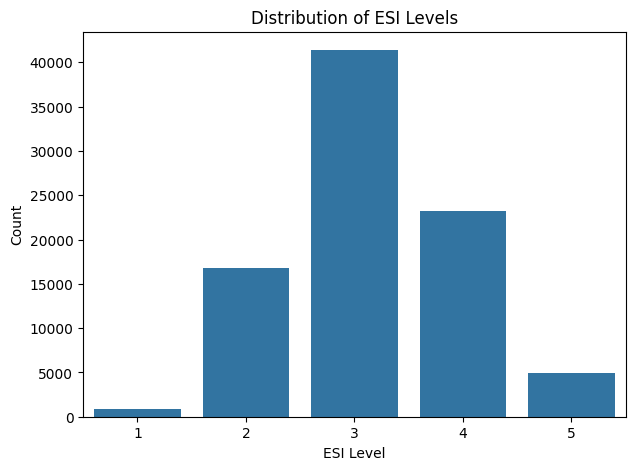

In [ ]:
# Emergency Severity Index (ESI) is a standardized 5-level triage algorithm used in emergency departments to categorize patient
# severity and predict the medical resources needed for their care
plt.figure(figsize=(7,5))
sns.countplot(x='esi_level', data=new_df)

plt.title("Distribution of ESI Levels")
plt.xlabel("ESI Level")
plt.ylabel("Count")

plt.show()


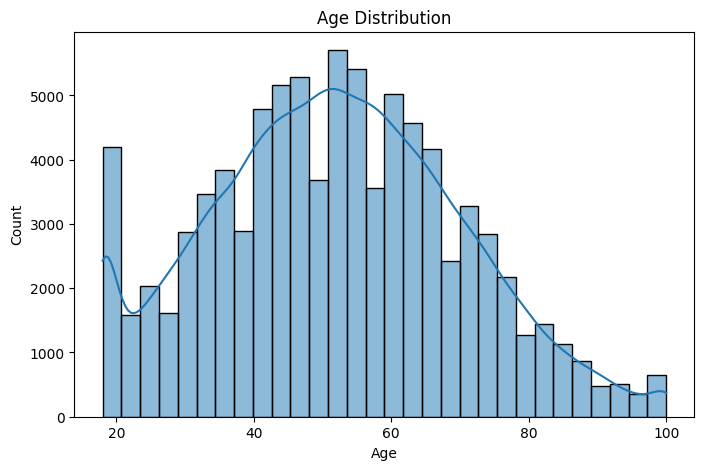

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(new_df['age'], bins=30, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")

plt.show()

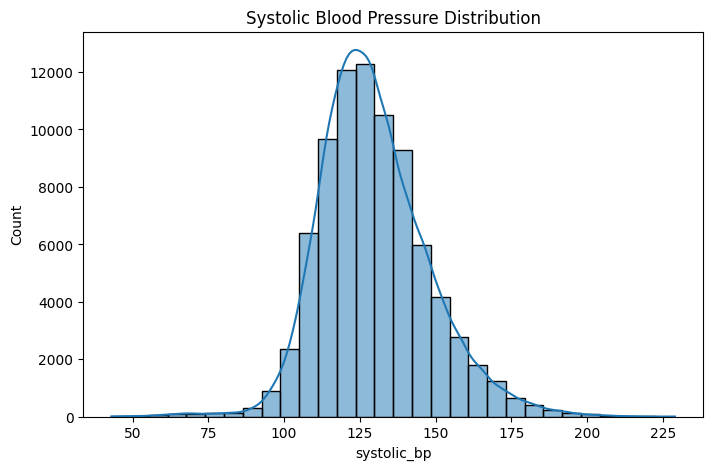

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(new_df['systolic_bp'], bins=30, kde=True)

plt.title("Systolic Blood Pressure Distribution")

plt.show()

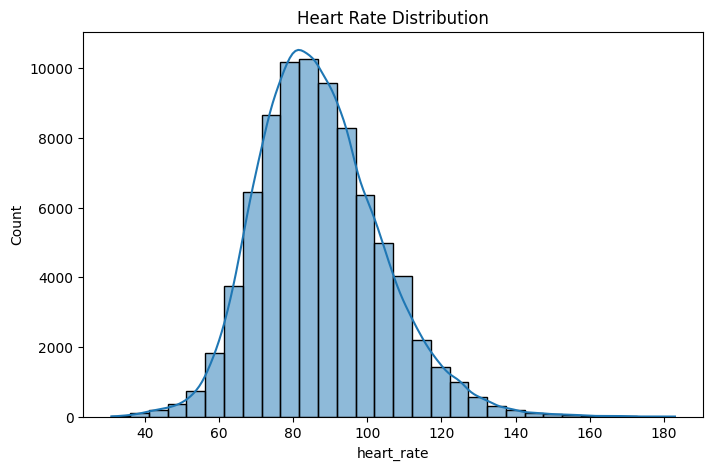

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(new_df['heart_rate'], bins=30, kde=True)

plt.title("Heart Rate Distribution")

plt.show()

In [ ]:
df.isnull().sum()

,0
site_id,0
country,0
age,0
sex,0
chief_complaint,0
clinical_notes,1555
systolic_bp,5492
diastolic_bp,5492
heart_rate,5492
respiratory_rate,5492


In [ ]:
numeric_df = new_df.select_dtypes(include='number')

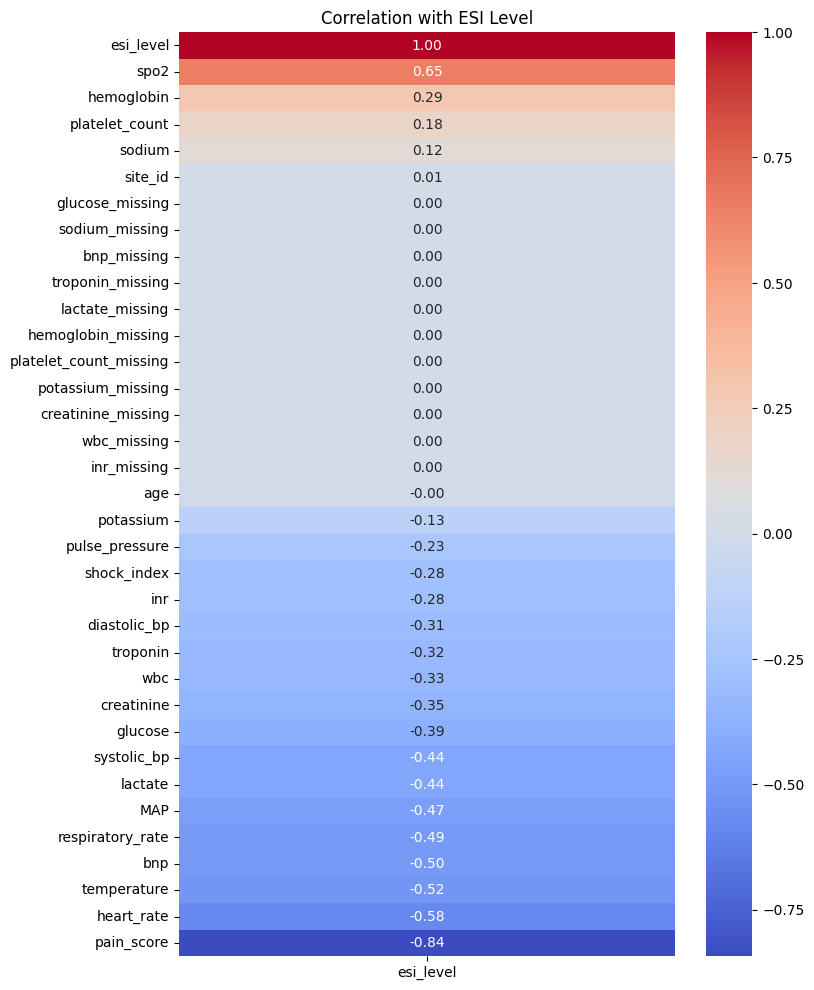

In [ ]:
corr_target = numeric_df.corr()['esi_level'].sort_values(ascending=False)

plt.figure(figsize=(8,12))
sns.heatmap(
    corr_target.to_frame(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation with ESI Level')
plt.show()

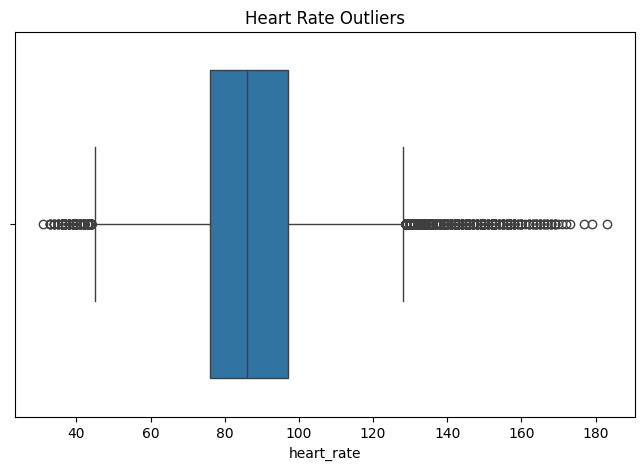

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=new_df['heart_rate'])

plt.title("Heart Rate Outliers")

plt.show()

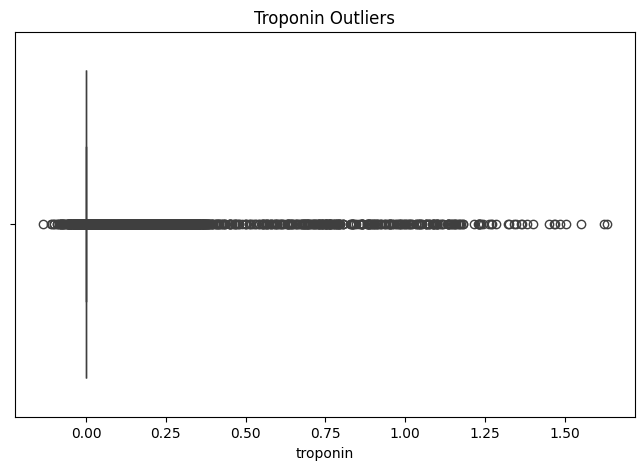

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x=new_df['troponin'])

plt.title("Troponin Outliers")

plt.show()

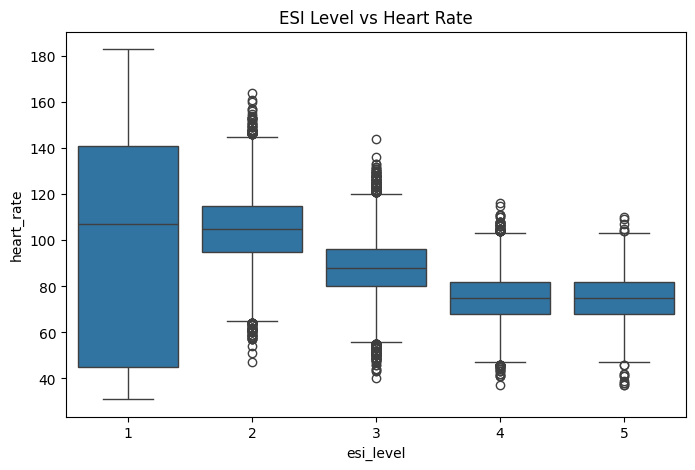

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='esi_level', y='heart_rate', data=new_df)

plt.title("ESI Level vs Heart Rate")

plt.show()

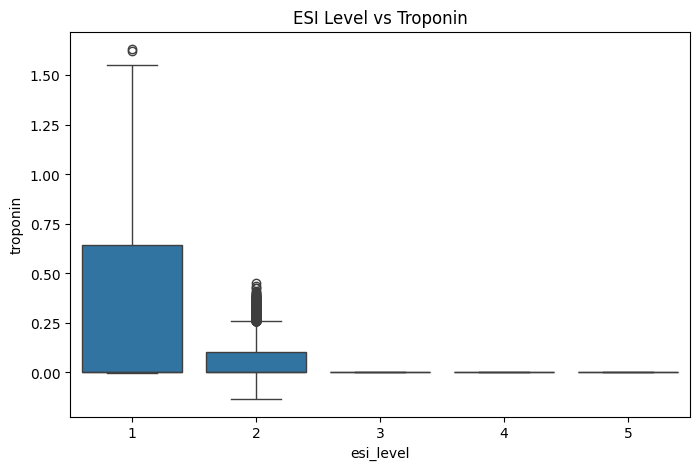

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(x='esi_level', y='troponin', data=new_df)

plt.title("ESI Level vs Troponin")

plt.show()

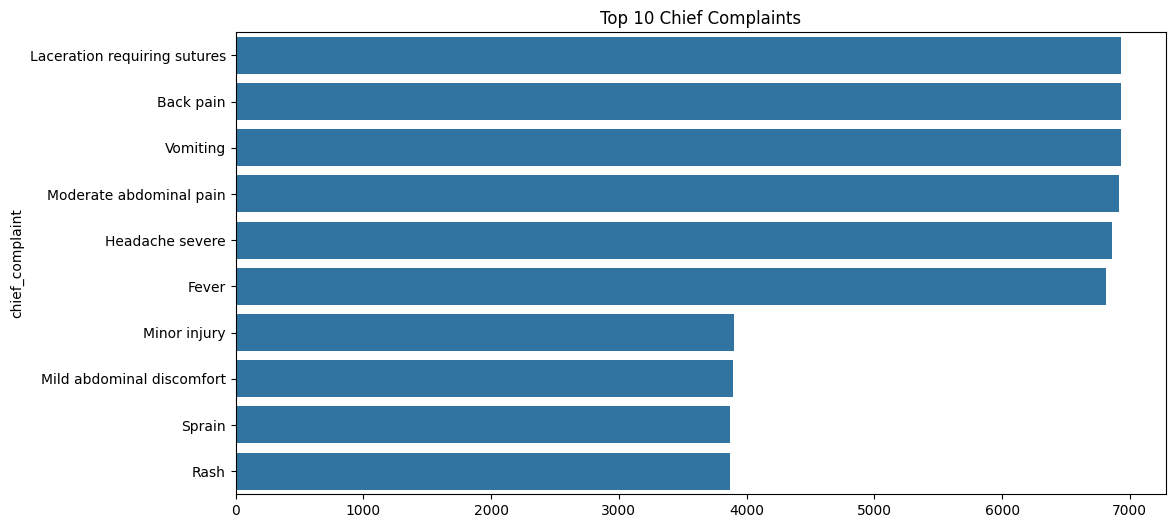

In [ ]:
top_complaints = df['chief_complaint'].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_complaints.values,
    y=top_complaints.index
)

plt.title("Top 10 Chief Complaints")

plt.show()

In [ ]:
# new_df = df[features+[target]]

In [ ]:
le = LabelEncoder()

new_df['sex'] = le.fit_transform(new_df['sex'])

In [ ]:
# for col in new_df.columns:
#     column_mean = new_df[col].mean()
#     new_df[i].fillna(column_mean, inplace = True)

for col in new_df.columns[2:]:
    column_mean = new_df[col].mean()
    new_df[col] = new_df[col].fillna(column_mean)


In [ ]:
new_df.isnull().sum()

,0
site_id,0
age,0
sex,0
systolic_bp,0
diastolic_bp,0
heart_rate,0
respiratory_rate,0
temperature,0
spo2,0
pain_score,0


In [ ]:
new_df.head()

,site_id,age,sex,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,...,creatinine_missing,glucose_missing,troponin_missing,bnp_missing,lactate_missing,inr_missing,shock_index,pulse_pressure,MAP,esi_level
0,1,59,0,122.0,88.0,80.0,16.0,38.2,97.2,6.0,...,0,0,0,0,0,0,0.655738,34.0,99.333333,3
1,1,67,1,138.0,68.0,82.0,18.0,36.7,98.4,2.0,...,0,0,0,0,0,0,0.594203,70.0,91.333333,5
2,1,58,0,114.0,76.0,85.0,16.0,37.6,97.8,1.0,...,0,0,0,0,0,0,0.745614,38.0,88.666667,4
3,1,23,0,137.0,81.0,79.0,20.0,38.0,91.6,4.0,...,1,1,1,1,1,1,0.576642,56.0,99.666667,3
4,1,64,0,141.0,71.0,99.0,21.0,37.8,98.8,8.0,...,1,1,1,1,1,1,0.702128,70.0,94.333333,2


In [ ]:
new_df['esi_level'].value_counts()

,count
esi_level,
3,41389
4,23199
2,16789
5,4933
1,924


In [ ]:
new_df['esi_level'].value_counts(normalize=True)*100

,proportion
esi_level,
3,47.445950
4,26.593989
2,19.245936
5,5.654905
1,1.059220


In [ ]:
new_df['esi_level'].value_counts()

,count
esi_level,
3,41389
4,23199
2,16789
5,4933
1,924


In [ ]:
new_df

,site_id,age,sex,systolic_bp,diastolic_bp,heart_rate,respiratory_rate,temperature,spo2,pain_score,...,creatinine_missing,glucose_missing,troponin_missing,bnp_missing,lactate_missing,inr_missing,shock_index,pulse_pressure,MAP,esi_level
0,1,59,0,122.0,88.0,80.0,16.0,38.2,97.2,6.0,...,0,0,0,0,0,0,0.655738,34.0,99.333333,3
1,1,67,1,138.0,68.0,82.0,18.0,36.7,98.4,2.0,...,0,0,0,0,0,0,0.594203,70.0,91.333333,5
2,1,58,0,114.0,76.0,85.0,16.0,37.6,97.8,1.0,...,0,0,0,0,0,0,0.745614,38.0,88.666667,4
3,1,23,0,137.0,81.0,79.0,20.0,38.0,91.6,4.0,...,1,1,1,1,1,1,0.576642,56.0,99.666667,3
4,1,64,0,141.0,71.0,99.0,21.0,37.8,98.8,8.0,...,1,1,1,1,1,1,0.702128,70.0,94.333333,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87229,6,37,0,104.0,69.0,85.0,18.0,37.2,98.5,3.0,...,0,0,0,0,0,0,0.817308,35.0,80.666667,4
87230,6,50,0,128.0,90.0,66.0,17.0,36.8,98.2,4.0,...,1,1,1,1,1,1,0.515625,38.0,102.666667,5
87231,6,39,1,162.0,94.0,117.0,24.0,37.8,92.7,6.0,...,1,1,1,1,1,1,0.722222,68.0,116.666667,2
87232,6,41,1,142.0,89.0,86.0,22.0,38.3,97.0,5.0,...,0,0,0,0,0,0,0.605634,53.0,106.666667,3


In [ ]:
X = new_df.drop('esi_level', axis=1)
y = new_df['esi_level'] - 1

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (69787, 35)
Testing Shape: (17447, 35)


In [ ]:
print(sorted(y.unique()))

[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
# ! pip install xgboost

# Model Comparision

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Naive Bayes": GaussianNB(),
    "XGBoost": XGBClassifier(
        n_estimators=600,
        max_depth=8,
        learning_rate=0.03,
        subsample=0.9,
        colsample_bytree=0.9,
        min_child_weight=3,
        gamma=0.1,
        reg_alpha=0.5,
        reg_lambda=2,
        objective='multi:softmax',
        eval_metric='mlogloss',
        random_state=42
    )
}

In [ ]:
from sklearn.metrics import accuracy_score

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results.append([name, accuracy])

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.8827
Decision Tree: 0.8411
Random Forest: 0.8964
Gradient Boosting: 0.8994
KNN: 0.7431
SVM: 0.8565
Naive Bayes: 0.8551
XGBoost: 0.9006


In [ ]:
results_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy']
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
7,XGBoost,0.900613
3,Gradient Boosting,0.899352
2,Random Forest,0.896372
0,Logistic Regression,0.882673
5,SVM,0.856537
6,Naive Bayes,0.855104
1,Decision Tree,0.841062
4,KNN,0.743050


In [ ]:
# results_df.to_csv("model_comparison_results.csv", index=False)

In [ ]:
# plt.figure(figsize=(10,5))

# sns.barplot(
#     x='Accuracy',
#     y='Model',
#     data=results_df
# )

# plt.title("Model Accuracy Comparison")

# plt.show()

In [ ]:
# from sklearn.metrics import classification_report

# print(classification_report(y_test, y_pred))

In [ ]:
# from sklearn.metrics import confusion_matrix
# import seaborn as sns
# import matplotlib.pyplot as plt

# cm = confusion_matrix(y_test, y_pred)

# plt.figure(figsize=(8,6))
# sns.heatmap(cm,
#             annot=True,
#             fmt='d',
#             cmap='Blues')
# plt.xlabel("Predicted")
# plt.ylabel("Actual")
# plt.show()

# Model Training

In [ ]:
print(X_train.columns)

Index(['site_id', 'age', 'sex', 'systolic_bp', 'diastolic_bp', 'heart_rate',
       'respiratory_rate', 'temperature', 'spo2', 'pain_score', 'wbc',
       'hemoglobin', 'platelet_count', 'sodium', 'potassium', 'creatinine',
       'glucose', 'troponin', 'bnp', 'lactate', 'inr', 'wbc_missing',
       'hemoglobin_missing', 'platelet_count_missing', 'sodium_missing',
       'potassium_missing', 'creatinine_missing', 'glucose_missing',
       'troponin_missing', 'bnp_missing', 'lactate_missing', 'inr_missing',
       'shock_index', 'pulse_pressure', 'MAP'],
      dtype='object')


In [ ]:
print(y_train)

84287    3
25707    1
70086    2
39837    2
70728    2
        ..
49815    2
16348    2
35537    2
42857    3
70192    2
Name: esi_level, Length: 69787, dtype: int64


In [ ]:
from xgboost import XGBClassifier
xgb =  XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=3,
    gamma=0.1,
    reg_alpha=0.5,
    reg_lambda=2,
    objective='multi:softmax',
    eval_metric='mlogloss',
    random_state=42
)
xgb.fit(X_train, y_train)

In [ ]:
y_pred = xgb.predict(X_test)

In [ ]:

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

In [ ]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plot_importance(
    xgb,
    max_num_features=20
)

plt.show()

In [ ]:
# import joblib

# joblib.dump(xgb, "xgboost_triage_model.pkl")

In [ ]:
# model = joblib.load("xgboost_triage_model.pkl")

In [ ]:
new_df.columns

In [ ]:
random_patients = X_test.sample(10)

In [ ]:
predictions = xgb.predict(random_patients)

In [ ]:
results = random_patients.copy()

results['Actual_ESI'] = y_test.loc[random_patients.index]

results['Predicted_ESI'] = predictions

print(results[['Actual_ESI','Predicted_ESI']])

